# Exercise 3

In [57]:
from functions import RandomnessTests
import numpy as np
import matplotlib.pyplot as plt
import random
random.seed(42)
import time
import tracemalloc
np.random.seed(42)
rng = np.random.default_rng(42)

## Part 1

### Exponential Distribution

In [58]:
def simulate_exponential(lam, n):
    U = rng.random(n)          # n uniforms
    X = -np.log(U) / lam           # inversion
    return X

exp_samples = simulate_exponential(lam=2, n=10000)

### Normal Distribution (at least with standard Box-Mueller)

In [59]:
def box_muller_normal(n):
    U1 = rng.random(n // 2)
    U2 = rng.random(n // 2)

    # Box-Muller transformation
    R = np.sqrt(-2 * np.log(U1))
    Z1 = R * np.cos(2 * np.pi * U2)
    Z2 = R * np.sin(2 * np.pi * U2)

    Z = np.concatenate([Z1, Z2])

    # Hvis n er ulige, generer en ekstra normal variabel
    if n % 2 == 1:
        U1 = rng.random()
        U2 = rng.random()
        R = np.sqrt(-2 * np.log(U1))
        extra = R * np.cos(2 * np.pi * U2)
        Z = np.append(Z, extra)

    return Z

def box_muller_general(n, mu, sigma):
    Z = box_muller_normal(n)
    return mu + sigma * Z


In [60]:
box_muller_samples = box_muller_general(n=10000, mu=0, sigma=1)

### Pareto Distribution

In [61]:
def simulate_pareto(n, k, beta=1.0):
    U = rng.random(n)
    X = beta * (U ** (-1.0 / k))
    return X

In [62]:
ks = [2.05, 2.5, 3, 4]
pareto_samples = {k: simulate_pareto(10000, k) for k in ks}

### Sammenlign

In [63]:
def theoretical_moments(dist, params):
    if dist == "exponential":
        lam = params["lam"]
        mean = 1 / lam
        var = 1 / (lam**2)
        return mean, var

    if dist == "normal":
        mu = params["mu"]
        sigma = params["sigma"]
        mean = mu
        var = sigma**2
        return mean, var

    if dist == "pareto":
        k = params["k"]
        beta = params["beta"]
        mean = beta * k / (k - 1) if k > 1 else np.nan
        var = beta**2 * k / ((k-1)**2 * (k-2)) if k > 2 else np.nan
        return mean, var


def verify_distribution(samples, dist, params):
    emp_mean = np.mean(samples)
    emp_var = np.var(samples)

    th_mean, th_var = theoretical_moments(dist, params)

    print("Empirical mean:", emp_mean)
    print("Theoretical mean:", th_mean)
    print()
    print("Empirical variance:", emp_var)
    print("Theoretical variance:", th_var)

def plot_distribution(samples, dist, params, bins=100):
    xs = np.linspace(min(samples), max(samples), 500)

    if dist == "exponential":
        lam = params["lam"]
        pdf = lam * np.exp(-lam * xs)

    elif dist == "normal":
        mu = params["mu"]
        sigma = params["sigma"]
        pdf = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((xs-mu)/sigma)**2)

    elif dist == "pareto":
        k = params["k"]
        beta = params["beta"]
        pdf = (k * beta**k) / (xs**(k+1))
        xs = xs[xs >= beta]  # Pareto support

    plt.hist(samples, bins=bins, density=True, alpha=0.5, label="Empirical")
    plt.plot(xs, pdf, "r", label="Theoretical PDF")
    plt.legend()
    plt.show()


Empirical mean: 0.5030850459924958
Theoretical mean: 0.5

Empirical variance: 0.24856413477957512
Theoretical variance: 0.25


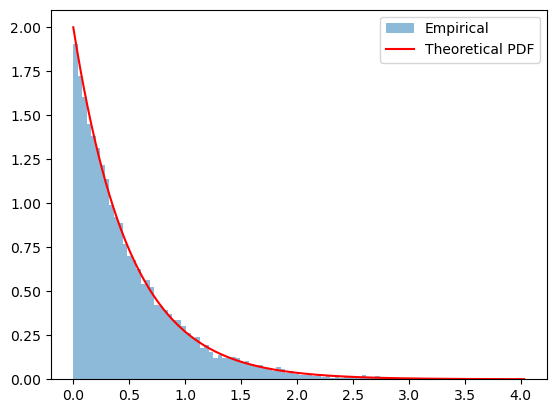

In [64]:
verify_distribution(exp_samples, "exponential", {"lam": 2})
plot_distribution(exp_samples, "exponential", {"lam": 2})

Empirical mean: 1.9722912608029546
Theoretical mean: 1.9523809523809526

Empirical variance: 7.859371446539335
Theoretical variance: 37.18820861678019


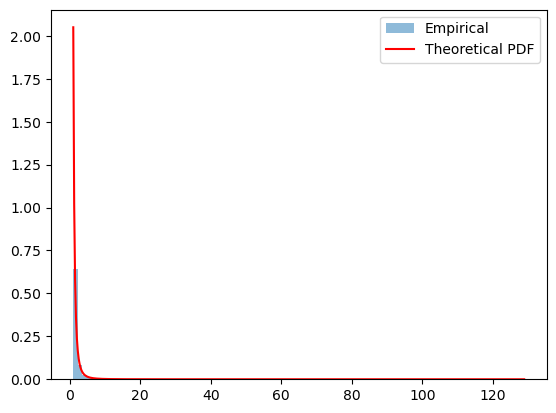

Empirical mean: 1.6650422525282509
Theoretical mean: 1.6666666666666667

Empirical variance: 1.8745711829191365
Theoretical variance: 2.2222222222222223


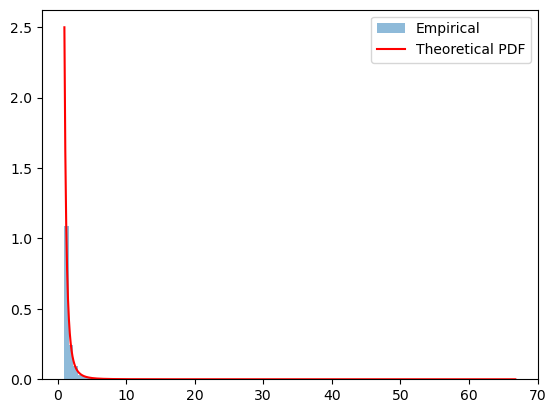

Empirical mean: 1.4976595937389592
Theoretical mean: 1.5

Empirical variance: 0.640467424371798
Theoretical variance: 0.75


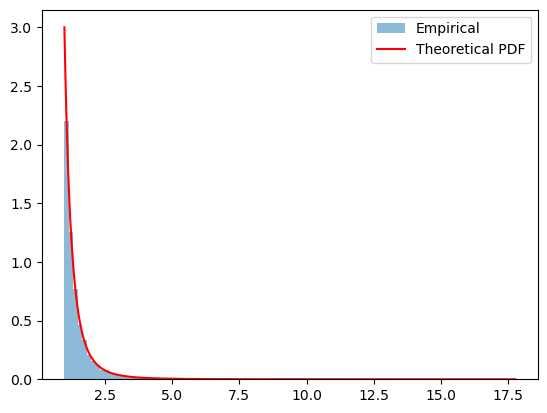

Empirical mean: 1.3370507806620644
Theoretical mean: 1.3333333333333333

Empirical variance: 0.24445349377101683
Theoretical variance: 0.2222222222222222


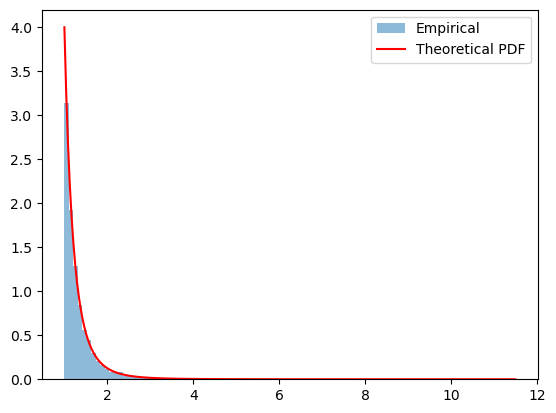

In [65]:
# pereto
for k in ks:
    verify_distribution(pareto_samples[k], "pareto", {"k": k, "beta": 1})
    plot_distribution(pareto_samples[k], "pareto", {"k": k, "beta": 1})

## Part 2

In [66]:
def estimate_probability(samples, condition):
    indicators = np.array([condition(x) for x in samples])
    return np.mean(indicators)

def estimate_expectation(samples, g):
    values = np.array([g(x) for x in samples])
    return np.mean(values)

def confidence_interval(samples, alpha=0.05):
    mean = np.mean(samples)
    std = np.std(samples, ddof=1)
    n = len(samples)
    z = 1.96  # for 95%
    return mean - z*std/np.sqrt(n), mean + z*std/np.sqrt(n)

In [67]:
X = simulate_pareto(100000, k=2.5, beta=1)

# P(X > 10)
p = estimate_probability(X, lambda x: x > 10)

# E[X]
m = estimate_expectation(X, lambda x: x)

# CI for E[X]
ci = confidence_interval(X)


Empirical mean: 1.6650422525282509
Theoretical mean: 1.6666666666666667

Empirical variance: 1.8745711829191365
Theoretical variance: 2.2222222222222223
P(X > 10): 0.00319
E[X]: 1.6664622717418862
CI for E[X]: (1.658085063032695, 1.6748394804510773)


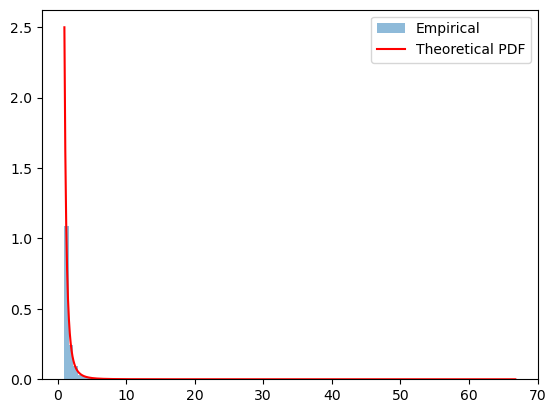

In [68]:
verify_distribution(pareto_samples[2.5], "pareto", {"k": 2.5, "beta": 1})
print("P(X > 10):", p)
print("E[X]:", m)
print("CI for E[X]:", ci)
plot_distribution(pareto_samples[2.5], "pareto", {"k": 2.5, "beta": 1})

## Part 3

In [69]:
def ci_mean_and_var_normal(mu_true=0.0, sigma2_true=1.0, n=10, n_rep=100):
    t_975 = 2.262      # t_{0.975, 9}
    chi2_975 = 19.02   # chi^2_{0.975, 9}
    chi2_025 = 2.70    # chi^2_{0.025, 9}

    mean_intervals = []
    var_intervals = []
    mean_contains = 0
    var_contains = 0

    for _ in range(n_rep):
        x = box_muller_normal(n)  # N(0,1)

        # sample mean and variance
        x_bar = np.mean(x)
        s2 = np.var(x, ddof=1)

        # 95% CI for mean (unknown variance → t)
        half_width_mean = t_975 * np.sqrt(s2 / n)
        ci_mean = (x_bar - half_width_mean, x_bar + half_width_mean)

        # 95% CI for variance (chi-square)
        df = n - 1
        ci_var = (df * s2 / chi2_975, df * s2 / chi2_025)

        mean_intervals.append(ci_mean)
        var_intervals.append(ci_var)

        if ci_mean[0] <= mu_true <= ci_mean[1]:
            mean_contains += 1
        if ci_var[0] <= sigma2_true <= ci_var[1]:
            var_contains += 1

    return mean_intervals, var_intervals, mean_contains, var_contains

In [70]:
mean_ints, var_ints, mean_hits, var_hits = ci_mean_and_var_normal()

print("Mean CIs containing true mean:", mean_hits, "ud af 100")
print("Var CIs containing true variance:", var_hits, "ud af 100")


Mean CIs containing true mean: 98 ud af 100
Var CIs containing true variance: 99 ud af 100


## Part 4

In [71]:
import numpy as np

def pareto_composition(n, k):
    p = k / (k + 1)

    # Bernoulli
    B = rng.random(n) < p

    U1 = rng.random(n)
    U2 = rng.random(n)

    Y1 = -np.log(U1) / k      
    Y2 = -np.log(U2) / (k+1)

    Y = np.where(B, Y1, Y2)

    X = 1 + Y
    return X

In [80]:
X1 = simulate_pareto(100000, k=2.5)        
X2 = pareto_composition(100000, k=2.5)

print(np.mean(X1), np.mean(X2))
print(np.var(X1), np.var(X2))


1.6629452340055761 1.3696981439640714
1.7158699427175717 0.14047266255460622
